In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/features.csv")
roads = gpd.read_file("../data/external/nyc_roads.gpkg")

# merge borough info onto features
roads['physicalid'] = roads['physicalid'].astype(str)
df['physicalid'] = df['physicalid'].astype(str)

roads_df = pd.DataFrame(roads.drop(columns='geometry'))
df = df.merge(roads_df[['physicalid','boroughcode']], on='physicalid', how='left')

borough_map = {'1':'Manhattan', '2':'Bronx', '3':'Brooklyn', '4':'Queens', '5':'Staten Island'}
df['borough'] = df['boroughcode'].astype(str).map(borough_map)

print(f"Shape: {df.shape}")
print("\nSegments per borough:")
print(df['borough'].value_counts(dropna=False))

Shape: (64475, 22)

Segments per borough:
borough
Queens           22742
Brooklyn         18174
Bronx             9684
Manhattan         7657
Staten Island     6218
Name: count, dtype: int64


In [3]:
FEATURES = [
    'posted_speed', 'number_total_lanes', 'number_travel_lanes',
    'segmentlength', 'streetwidth', 'trafdir_enc', 'has_bike_lane',
    'rw_type', 'crash_density'
]

X = df[FEATURES]
y = df['risk_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

print(f"Model trained. Test size: {X_test.shape}")

Model trained. Test size: (12895, 9)


=== BOROUGH LEVEL F1 SCORES ===

Manhattan       segments: 1489   F1: 0.837
Brooklyn        segments: 3617   F1: 0.848
Queens          segments: 4600   F1: 0.852
Bronx           segments: 1930   F1: 0.830
Staten Island   segments: 1259   F1: 0.835


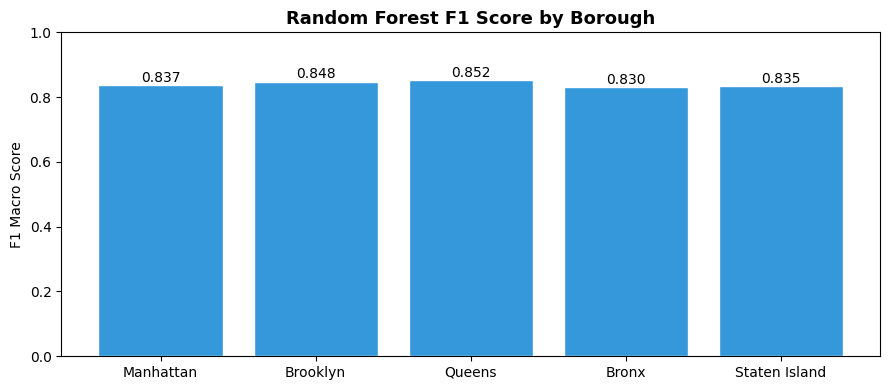

Saved borough_f1.png


In [4]:
df['predicted_risk'] = rf.predict(df[FEATURES].fillna(0))
df_test = df.loc[X_test.index].copy()
df_test['predicted'] = rf.predict(X_test.fillna(0))

print("=== BOROUGH LEVEL F1 SCORES ===\n")
borough_results = {}

for borough in ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']:
    subset = df_test[df_test['borough'] == borough]
    if len(subset) < 10:
        continue
    f1 = f1_score(subset['risk_label'], subset['predicted'], 
                  average='macro', zero_division=0)
    borough_results[borough] = f1
    print(f"{borough:<15} segments: {len(subset):>4}   F1: {f1:.3f}")

# bar chart
plt.figure(figsize=(9, 4))
bars = plt.bar(borough_results.keys(), borough_results.values(), 
               color='#3498db', edgecolor='white')
plt.title('Random Forest F1 Score by Borough', fontsize=13, fontweight='bold')
plt.ylabel('F1 Macro Score')
plt.ylim(0, 1)
for bar, val in zip(bars, borough_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, 
             f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/figures/borough_f1.png", dpi=150)
plt.show()
print("Saved borough_f1.png")

In [ ]:
y_pred = rf.predict(X_test.fillna(0))

print("=== FULL CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred, 
      target_names=['Low', 'Moderate', 'High']))

=== FULL CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

         Low       0.96      0.93      0.95      9042
    Moderate       0.71      0.77      0.74      2532
        High       0.85      0.85      0.85      1321

    accuracy                           0.89     12895
   macro avg       0.84      0.85      0.85     12895
weighted avg       0.90      0.89      0.90     12895

